# Concise Implementation of Softmax Regression

**Just as high-level APIs**
of deep learning frameworks
**made it much easier to implement linear regression**
(**we will find it similarly**) (or possibly more)
convenient for implementing classification models. Let us stick with the Fashion-MNIST dataset
and keep the batch size at 256 as in the implementation from the scratch.


In [ ]:
# Force pip to install the stable 1st Edition version of d2l
!pip install d2l==0.17.6 --no-deps

import torch
from torch import nn
from d2l import torch as d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.6/112.6 kB 3.7 MB/s eta 0:00:00


In [ ]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 221kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.4MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Initializing Model Parameters

As mentioned before,
**the output layer of softmax regression
is a fully-connected layer.**
Therefore, to implement our model,
we just need to add one fully-connected layer
with 10 outputs to our `Sequential`.
Again, here, the `Sequential` is not really necessary,
but we might as well form the habit since it will be ubiquitous
when implementing deep models.
Again, we initialize the weights at random
with zero mean and standard deviation 0.01.


In [ ]:
# PyTorch does not implicitly reshape the inputs. Thus we define the flatten
# layer to reshape the inputs before the linear layer in our network
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);
# The function "apply" applies a function to all elements of a tensor - so here it will initialize
# the weights. You can read more here, if you want https://pytorch.org/docs/stable/generated/torch.nn.Module.html

## Softmax Implementation Revisited

In the previous example,
we calculated our model's output
and then ran this output through the cross-entropy loss.
Mathematically, that is a perfectly reasonable thing to do.
However, from a computational perspective,
exponentiation can be a source of numerical stability issues.

Recall that the softmax function calculates
$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$,
where $\hat y_j$ is the $j^\mathrm{th}$ element of
the predicted probability distribution $\hat{\mathbf{y}}$
and $o_j$ is the $j^\mathrm{th}$ element of the logits
$\mathbf{o}$.
If some of the $o_k$ are very large (i.e., very positive),
then $\exp(o_k)$ might be larger than the largest number
we can have for certain data types (i.e., *overflow*).
This would make the denominator (and/or numerator) `inf` (infinity)
and we wind up encountering either 0, `inf`, or `nan` (not a number) for $\hat y_j$.
In these situations we do not get a well-defined
return value for cross-entropy.


One trick to get around this is to first subtract $\max(o_k)$
from all $o_k$ before proceeding with the softmax calculation.
You can see that this shifting of each $o_k$ by constant factor
does not change the return value of softmax:

$$
\begin{aligned}
\hat y_j & =  \frac{\exp(o_j - \max(o_k))\exp(\max(o_k))}{\sum_k \exp(o_k - \max(o_k))\exp(\max(o_k))} \\
& = \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}.
\end{aligned}
$$


After the subtraction and normalization step,
it might be possible that some $o_j - \max(o_k)$ have large negative values
and thus that the corresponding $\exp(o_j - \max(o_k))$ will take values close to zero.
These might be rounded to zero due to finite precision (i.e., *underflow*),
making $\hat y_j$ zero and giving us `-inf` for $\log(\hat y_j)$.
A few steps down the road in backpropagation,
we might find ourselves faced with a screenful
of the dreaded `nan` results.

Fortunately, we are saved by the fact that
even though we are computing exponential functions,
we ultimately intend to take their log
(when calculating the cross-entropy loss).
By combining these two operators
softmax and cross-entropy together,
we can escape the numerical stability issues
that might otherwise plague us during backpropagation.
As shown in the equation below, we avoid calculating $\exp(o_j - \max(o_k))$
and can use instead $o_j - \max(o_k)$ directly due to the canceling in $\log(\exp(\cdot))$:

$$
\begin{aligned}
\log{(\hat y_j)} & = \log\left( \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}\right) \\
& = \log{(\exp(o_j - \max(o_k)))}-\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)} \\
& = o_j - \max(o_k) -\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)}.
\end{aligned}
$$

We will want to keep the conventional softmax function handy
in case we ever want to evaluate the output probabilities by our model.
But instead of passing softmax probabilities into our new loss function,
we will just
**pass the logits and compute the softmax and its log
all at once inside the cross-entropy loss function,**
which does smart things like the ["LogSumExp trick"](https://en.wikipedia.org/wiki/LogSumExp).


In [ ]:
loss = nn.CrossEntropyLoss()

## Optimization Algorithm

Here, we **use minibatch stochastic gradient descent**
with a learning rate of 0.1 as the optimization algorithm.
Note that this is the same as we applied in the linear regression example
and it illustrates the general applicability of the optimizers.


In [ ]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

## Training

Next we **call the training function defined** earlier in the implementation from the scratch to train the model.


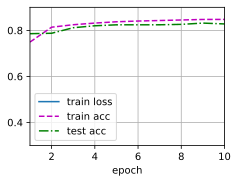

In [ ]:
num_epochs = 10
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

As before, this algorithm converges to a solution
that achieves a decent accuracy,
albeit this time with fewer lines of code than before.


## Summary

* Using high-level APIs, we can implement softmax regression much more concisely.
* From a computational perspective, implementing softmax regression has intricacies. Note that in many cases, a deep learning framework takes additional precautions beyond these most well-known tricks to ensure numerical stability, saving us from even more pitfalls that we would encounter if we tried to code all of our models from scratch in practice.

## Exercises



1. Try adjusting the hyperparameters, such as the batch size, number of epochs, and learning rate, to see what the results are.



Exercise 1: Hyperparameter Tuning

We experiment with three key hyperparameters: batch size, number of epochs, and learning rate.

Batch size: smaller batches introduce more noise in gradient updates, which can help escape local minima but slows down training per epoch. Larger batches are faster but may generalise slightly worse.
Learning rate: too high → the loss oscillates and may diverge; too low → convergence is very slow. A moderate value (0.1) works well here.
Epochs: more epochs allow more passes over the data. However, too many epochs can lead to overfitting (see Exercise 2).

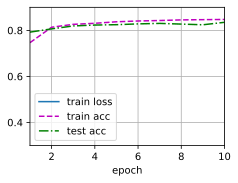

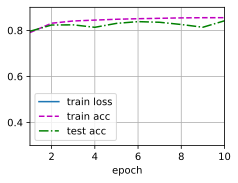

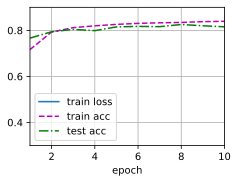

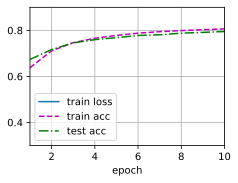

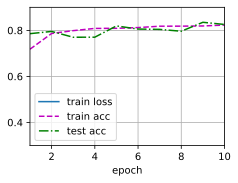

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

# Experiment configurations: (batch_size, num_epochs, learning_rate)
configs = [
    (256, 10, 0.1),   # baseline
    (64,  10, 0.1),   # smaller batch: noisier, slower per epoch
    (512, 10, 0.1),   # larger batch: faster, may generalise slightly worse
    (256, 10, 0.01),  # low LR: slow convergence
    (256, 10, 0.5),   # high LR: risk of divergence
]

for batch_size, num_epochs, lr in configs:
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

    net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
    net.apply(lambda m: nn.init.normal_(m.weight, std=0.01)
              if type(m) == nn.Linear else None)

    loss    = nn.CrossEntropyLoss()
    trainer = torch.optim.SGD(net.parameters(), lr=lr)

    print(f"batch_size={batch_size}, epochs={num_epochs}, lr={lr}")
    d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

2. Increase the number of epochs for training. Why might the test accuracy decrease after a while? How could we fix this?

Exercise 2: Effect of increasing the number of epochs

We train for many epochs and monitor both training and test accuracy over time to observe overfitting.

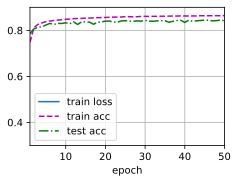

In [ ]:
# Train for many epochs to observe overfitting
batch_size = 256
num_epochs = 50  # deliberately high to show the effect
lr         = 0.1

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
net.apply(lambda m: nn.init.normal_(m.weight, std=0.01)
          if type(m) == nn.Linear else None)

loss    = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr)

d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

Why does test accuracy decrease after a while?

This phenomenon is called overfitting. After many epochs the model has seen the training data so many times that it begins to memorise the specific examples rather than learning generalisable patterns. As a result:

Training accuracy continues to rise (or plateau near 100%).
Test accuracy peaks and then decreases, because the model fails to generalise to unseen data.

How to fix it:

Early stopping: monitor validation accuracy each epoch and stop when it no longer improves.
Weight decay (L2 regularisation): add a penalty for large weights, discouraging the model from over-specialising. In PyTorch: SGD(..., weight_decay=1e-4).
Dropout: randomly zero out activations during training (not applicable to this simple linear model, but important for deeper networks).
More training data / data augmentation: more diverse examples make memorisation harder.

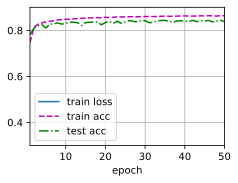

In [ ]:
batch_size = 256
num_epochs = 50
lr = 0.1

# Reload fresh data iterators
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

# Fresh model
net2 = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
net2.apply(lambda m: nn.init.normal_(m.weight, std=0.01)
           if type(m) == nn.Linear else None)

loss = nn.CrossEntropyLoss()

# Optimizer tied to net2 (not net!)
trainer_wd = torch.optim.SGD(
    net2.parameters(), lr=lr, weight_decay=1e-4
)

d2l.train_ch3(net2, train_iter, test_iter, loss, num_epochs, trainer_wd)

[Discussions](https://discuss.d2l.ai/t/53)
